# KMeans Calculation Proof

This notebook demonstrates the process of assigning players to teams using KMeans clustering on jersey colors. We will walk through the steps of:
1. Loading a sample frame and ground truth bounding boxes.
2. Extracting player crops and their representative jersey colors.
3. Applying KMeans clustering to separate players into two teams.
4. Visualizing the results.

This process mirrors the logic implemented in `footballanalytix.players`.

In [8]:
import sys
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Add project root to path to import footballanalytix
sys.path.append(os.path.abspath(os.path.join('..')))

from footballanalytix.players import extract_jersey_color

# Setup matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

## 1. Load Sample Data

We will use a sample frame from the dataset and the corresponding ground truth annotations to get player bounding boxes.

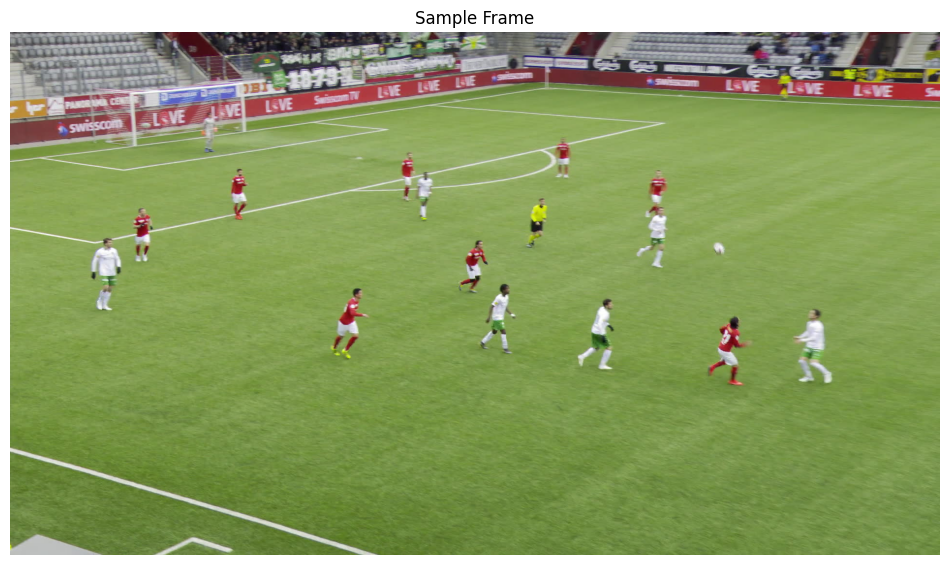

Found 18 objects in Frame 522


In [30]:
# Paths
n_frame = 522
frame_path = f'../Data/Sample/SNGS-131/Frames/000{n_frame}.jpg'
gt_path = '../Data/Sample/SNGS-131/SNGS-131_tracking_gt.json'

# Load Image
frame = cv2.imread(frame_path)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.title("Sample Frame")
plt.axis('off')
plt.show()

# Load Ground Truth
with open(gt_path, 'r') as f:
    gt_data = json.load(f)

# Get boxes for Frame 1
frame_1_data = gt_data['frames'][str(n_frame)]
print(f"Found {len(frame_1_data)} objects in Frame {n_frame}")

## 2. Extract Jersey Colors

We iterate through the detected objects. We are only interested in objects with `class_id == 1` (Player).
We use the `extract_jersey_color` function from `footballanalytix.players`. This function:
1. Crops the player using the bounding box.
2. **Takes the upper half of the crop**. This is a crucial step because the jersey is typically in the upper body, while shorts and socks (which might be different colors) are in the lower half.
3. Calculates the mean RGB color of this upper half.

In [31]:
player_colors = []
player_bboxes = []
player_crops = []
player_upper_halves = []

for obj in frame_1_data:
    # Filter for players (class_id 1)
    if obj['class_id'] != 1:
        continue
        
    bbox = obj['bbox'] # [x1, y1, x2, y2]
    
    # Extract color
    color = extract_jersey_color(frame_rgb, np.array(bbox))
    
    if color is not None:
        player_colors.append(color)
        player_bboxes.append(bbox)
        
        # For visualization, let's save the crop and the upper half
        x1, y1, x2, y2 = map(int, bbox)
        crop = frame_rgb[y1:y2, x1:x2]
        player_crops.append(crop)
        
        # Replicate the logic: Upper half
        upper_half = crop[: max(1, crop.shape[0] // 2), :]
        player_upper_halves.append(upper_half)

player_colors = np.array(player_colors)
print(f"Extracted colors for {len(player_colors)} players.")

Extracted colors for 14 players.


Let's visualize the process: **Full Crop -> Upper Half -> Extracted Color**.

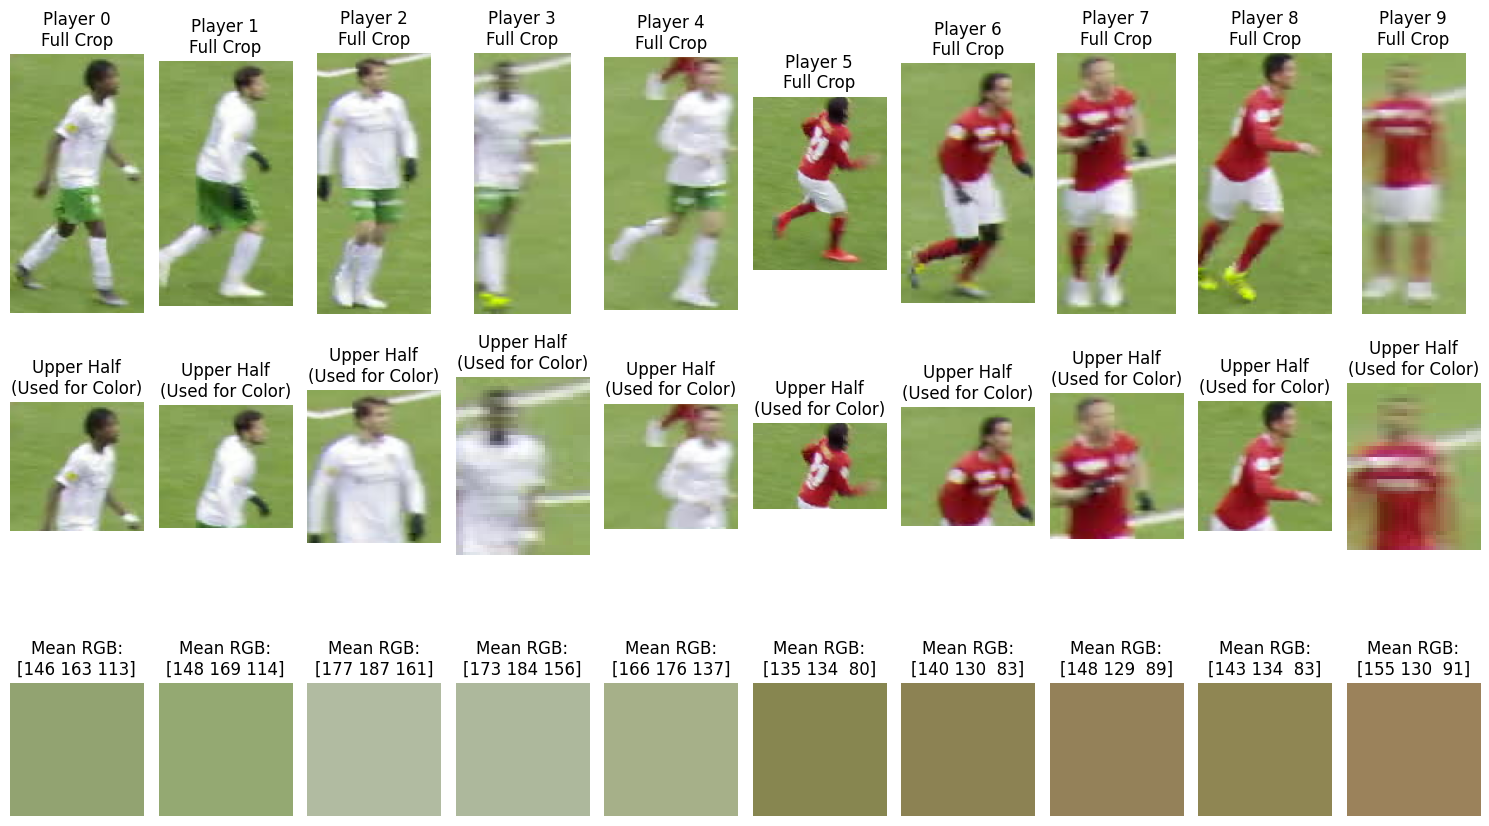

In [32]:
num_samples = 10
fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))

for i in range(num_samples):
    if i >= len(player_crops): break
    
    # 1. Full Crop
    axes[0, i].imshow(player_crops[i])
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Player {i}\nFull Crop")
    
    # 2. Upper Half
    axes[1, i].imshow(player_upper_halves[i])
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Upper Half\n(Used for Color)")
    
    # 3. Extracted Color
    color_patch = np.zeros((50, 50, 3), dtype=np.uint8)
    color_patch[:, :] = player_colors[i].astype(np.uint8)
    
    axes[2, i].imshow(color_patch)
    axes[2, i].axis('off')
    axes[2, i].set_title(f"Mean RGB:\n{player_colors[i].astype(int)}")

plt.tight_layout()
plt.show()

## 3. Apply KMeans Clustering

We use KMeans with `n_clusters=2` to separate the colors into two teams.

In [33]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(player_colors)

team_centers = kmeans.cluster_centers_
labels = kmeans.labels_

print("Cluster Centers (Team Colors):")
print(team_centers)
print("\nLabels:", labels)

Cluster Centers (Team Colors):
[[148.55788304 131.67557989  87.60845813]
 [161.70574004 175.67570682 135.2176338 ]]

Labels: [1 1 1 1 1 0 0 0 0 0 0 0 0 1]


## 4. Visualize Clusters

We can visualize the color space and the clusters. Since RGB is 3D, we can plot it in 3D.

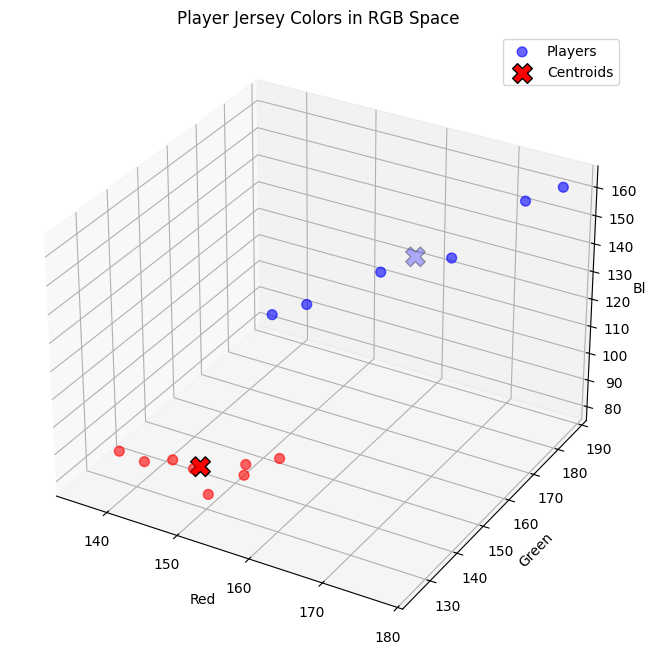

In [34]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot player colors
# We color the points by their assigned cluster label for clarity
colors = ['red' if l == 0 else 'blue' for l in labels]

ax.scatter(player_colors[:, 0], player_colors[:, 1], player_colors[:, 2], c=colors, s=50, alpha=0.6, label='Players')

# Plot centers
ax.scatter(team_centers[:, 0], team_centers[:, 1], team_centers[:, 2], c=['red', 'blue'], s=200, marker='X', edgecolors='black', label='Centroids')

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title('Player Jersey Colors in RGB Space')
ax.legend()

plt.show()

## 5. Visualize Results on Frame

Finally, let's draw the bounding boxes on the original frame, colored by the assigned team.
We'll use Red for Cluster 0 and Blue for Cluster 1 (arbitrary assignment for visualization).

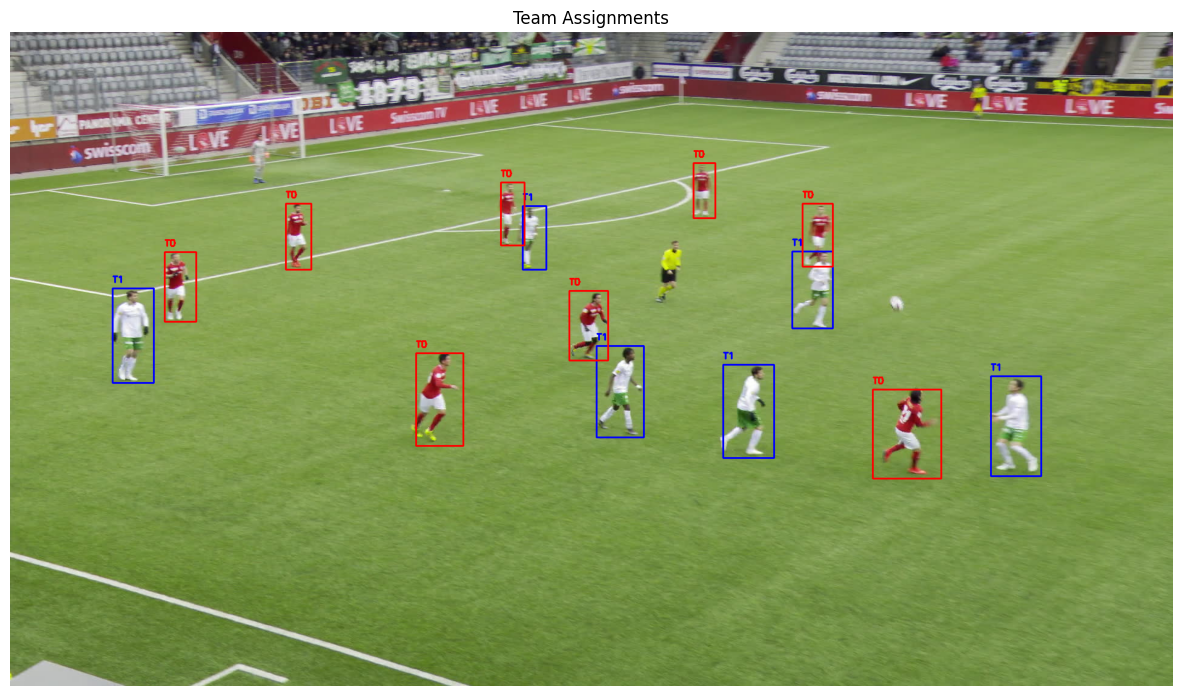

In [35]:
output_frame = frame_rgb.copy()

# Define colors for visualization (RGB)
vis_colors = [
    (255, 0, 0),   # Red for Team 0
    (0, 0, 255)    # Blue for Team 1
]

for i, bbox in enumerate(player_bboxes):
    team_id = labels[i]
    color = vis_colors[team_id]
    
    x1, y1, x2, y2 = map(int, bbox)
    
    # Draw rectangle
    cv2.rectangle(output_frame, (x1, y1), (x2, y2), color, 2)
    
    # Put label
    cv2.putText(output_frame, f"T{team_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(15, 10))
plt.imshow(output_frame)
plt.title("Team Assignments")
plt.axis('off')
plt.show()